DATA ANALYSIS FOR WATER POTABILITY DAY 5

In [1]:
!pip install snowflake-connector-python pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 2.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found 

In [102]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
from sklearn.preprocessing import (
StandardScaler,
MinMaxScaler,
PowerTransformer
)

In [3]:
import snowflake.connector

conn = snowflake.connector.connect(
    user='Mano2006',
    password='Rammanoshankar$2006',
    account='GQHJOCN-VI31859',
    warehouse='COMPUTE_WH',
    database='RMSDB',
    schema='PUBLIC'
)

print("Connected")

Connected


In [74]:
query = 'SELECT * FROM  water'
data = pd.read_sql(query,conn)


print(data.head())

/tmp/ipykernel_5344/200110891.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql(query,conn)


         PH    HARDNESS        SOLIDS  CHLORAMINES     SULFATE  CONDUCTIVITY  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [76]:
print(data.columns)

Index(['PH', 'HARDNESS', 'SOLIDS', 'CHLORAMINES', 'SULFATE', 'CONDUCTIVITY',
       'ORGANIC_CARBON', 'TRIHALOMETHANES', 'TURBIDITY', 'POTABILITY'],
      dtype='object')


In [77]:
data.dtypes

,0
PH,float64
HARDNESS,float64
SOLIDS,float64
CHLORAMINES,float64
SULFATE,float64
CONDUCTIVITY,float64
ORGANIC_CARBON,float64
TRIHALOMETHANES,float64
TURBIDITY,float64
POTABILITY,int64


In [78]:
data.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [79]:
data.shape

(3276, 10)

In [80]:
data.isnull().sum()

,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


In [81]:
imputer = SimpleImputer(strategy='median')

data[['PH','SULFATE','TRIHALOMETHANES']] = imputer.fit_transform(
data[['PH','SULFATE','TRIHALOMETHANES']]
)

data.isnull().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0
POTABILITY,0


In [82]:
data.duplicated().sum()

np.int64(0)

In [83]:
data = data.drop_duplicates()

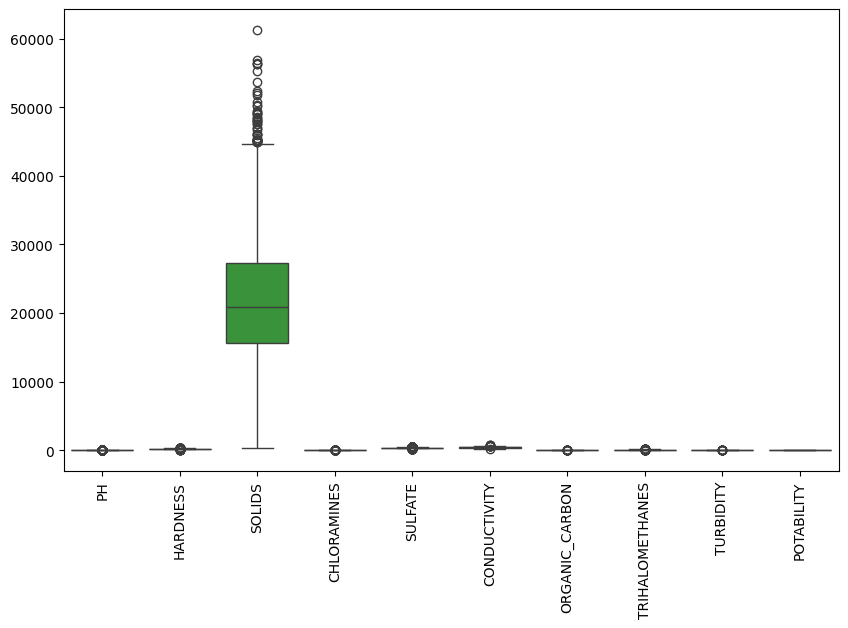

In [84]:
plt.figure(figsize=(10,6))

sns.boxplot(data=data)

plt.xticks(rotation=90)

plt.show()

In [90]:
Q1 = data.quantile(0.25)

Q3 = data.quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

data = data[~((data<lower)|(data>upper)).any(axis=1)]

print(data.shape)

(2217, 10)


In [91]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in data.columns:

    if data[col].dtype == 'object':

        data[col] = encoder.fit_transform(
        data[col]
        )

print(data.head())

         PH    HARDNESS        SOLIDS  CHLORAMINES     SULFATE  CONDUCTIVITY  \
0  7.036752  204.890455  20791.318981     7.300212  368.516441    564.308654   
2  8.099124  224.236259  19909.541732     9.275884  333.073546    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   
5  5.584087  188.313324  28748.687739     7.544869  326.678363    280.467916   

   ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0       10.379783        86.990970   2.963135           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
5        8.399735        54.917862   2.559708           0  


In [97]:
from scipy.stats import zscore
from scipy.stats.mstats import winsorize
cols = [

'PH',
'HARDNESS',
'SOLIDS',
'CHLORAMINES',
'SULFATE',
'CONDUCTIVITY',
'ORGANIC_CARBON',
'TRIHALOMETHANES',
'TURBIDITY'

]

z = np.abs(
zscore(
data[cols]
)
)

outliers = data[
(z > 3).any(axis=1)
]

print(outliers)


Empty DataFrame
Columns: [PH, HARDNESS, SOLIDS, CHLORAMINES, SULFATE, CONDUCTIVITY, ORGANIC_CARBON, TRIHALOMETHANES, TURBIDITY, POTABILITY]
Index: []


In [98]:
for col in cols:

    data[col] = winsorize(
    data[col],
    limits=[0.05,0.05]
    )

print(data.head())

         PH    HARDNESS        SOLIDS  CHLORAMINES     SULFATE  CONDUCTIVITY  \
0  7.036752  204.890455  20791.318981     7.300212  368.516441    564.203178   
2  8.099124  224.236259  19909.541732     9.275884  333.073546    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.042583  181.101509  17978.986339     6.546600  310.135738    398.410813   
5  5.584087  188.313324  28748.687739     7.544869  326.678363    300.019910   

   ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0       10.379783        86.990970   2.963135           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524        91.118698   4.628771           0  
4       11.558279        40.546037   4.075075           0  
5        8.857706        54.917862   2.715187           0  


In [100]:
data['SOLIDS_LOG'] = np.log1p(
data['SOLIDS']
)

data['CONDUCTIVITY_LOG'] = np.log1p(
data['CONDUCTIVITY']
)

data.head()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY,SOLIDS_LOG,CONDUCTIVITY_LOG
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.203178,10.379783,86.990970,2.963135,0,9.942339,6.337185
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0,9.899005,6.039317
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,91.118698,4.628771,0,9.999680,5.897886
4,9.042583,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,40.546037,4.075075,0,9.797015,5.989990
5,5.584087,188.313324,28748.687739,7.544869,326.678363,300.019910,8.857706,54.917862,2.715187,0,10.266382,5.707176


In [103]:
pt = PowerTransformer()

data[['SULFATE','TRIHALOMETHANES']] = pt.fit_transform(

data[['SULFATE','TRIHALOMETHANES']]

)

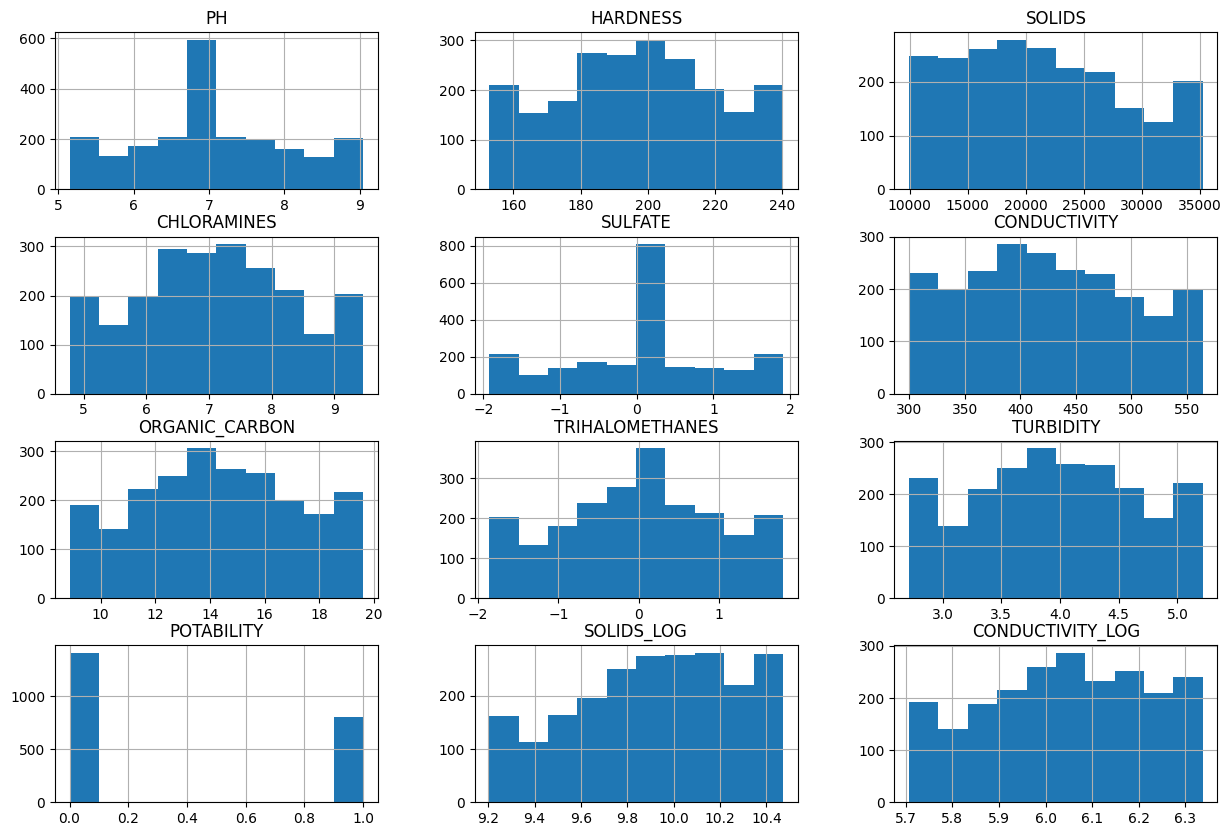

In [104]:
data.hist(figsize=(15,10))

plt.show()

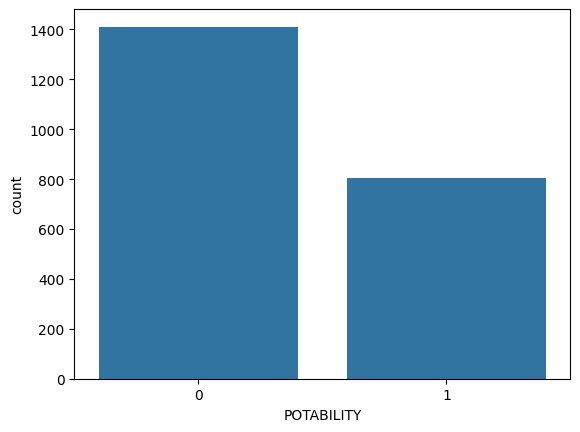

In [107]:
sns.countplot(
x='POTABILITY',
data=data
)

plt.show()

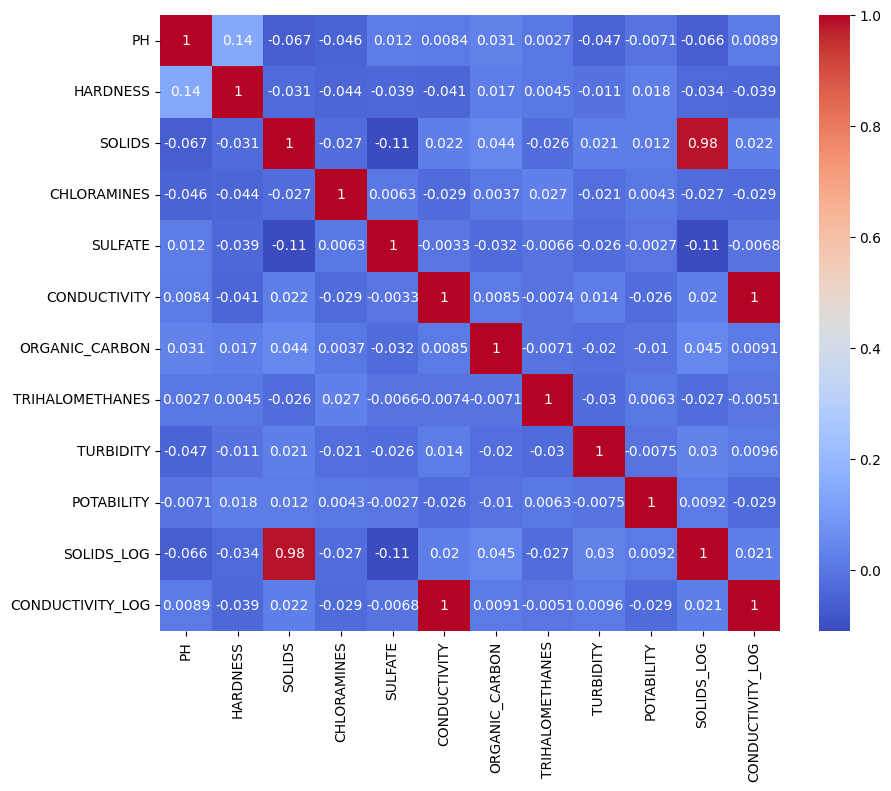

In [108]:
corr = data.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
corr,
annot=True,
cmap='coolwarm'
)

plt.show()

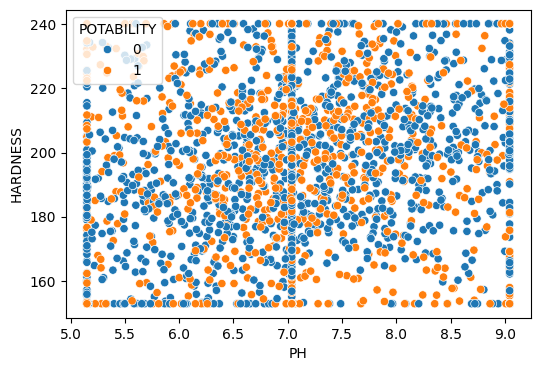

In [109]:
plt.figure(figsize=(6,4))

sns.scatterplot(
x='PH',
y='HARDNESS',
hue='POTABILITY',
data=data
)

plt.show()

In [110]:
sns.pairplot(
data,
hue='POTABILITY'
)

plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [111]:
X = data.drop(
'POTABILITY',
axis=1
)

y = data['POTABILITY']

In [112]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [113]:
mm = MinMaxScaler()

X_minmax = mm.fit_transform(X)

print(X_minmax)

[[0.48464397 0.59608498 0.42842386 ... 0.09920736 0.58265371 1.        ]
 [0.75759814 0.81779747 0.3935985  ... 0.13633715 0.54842025 0.52719937]
 [0.81351659 0.70476415 0.47688751 ... 0.76564874 0.62795228 0.30270904]
 ...
 [1.         0.26226588 0.91674422 ... 0.23354117 0.95130623 0.5772375 ]
 [0.         0.89077215 0.08057795 ... 0.7976129  0.14742032 0.46657931]
 [0.6999297  0.48390786 0.29465035 ... 0.         0.44218175 0.13847095]]


In [114]:
X_train,X_test,y_train,y_test = train_test_split(

X_scaled,

y,

test_size=0.2,

random_state=42

)

print(X_train.shape)

(1773, 11)


In [115]:
svm = SVC(

kernel='rbf',

C=1,

gamma='scale'

)

svm.fit(
X_train,
y_train
)

pred = svm.predict(
X_test
)

In [116]:
acc = accuracy_score(
y_test,
pred
)

print(
"Accuracy =",
acc
)

Accuracy = 0.6441441441441441


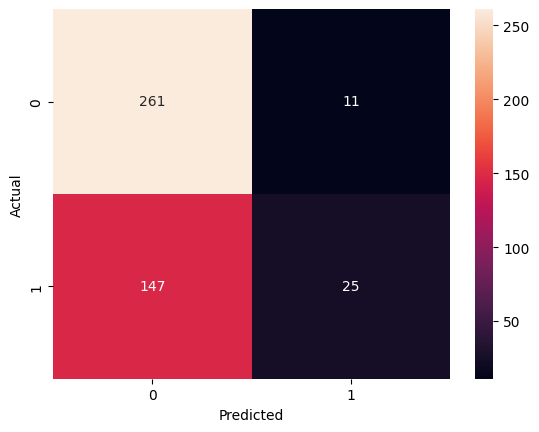

In [117]:
cm = confusion_matrix(
y_test,
pred
)

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [118]:
print(

classification_report(

y_test,

pred

)

)

              precision    recall  f1-score   support

           0       0.64      0.96      0.77       272
           1       0.69      0.15      0.24       172

    accuracy                           0.64       444
   macro avg       0.67      0.55      0.50       444
weighted avg       0.66      0.64      0.56       444



In [119]:
dt = DecisionTreeClassifier()

dt.fit(
X_train,
y_train
)

pred_dt = dt.predict(
X_test
)

print(
accuracy_score(
y_test,
pred_dt
)
)

0.5337837837837838


In [120]:
rf = RandomForestClassifier()

rf.fit(
X_train,
y_train
)

pred_rf = rf.predict(
X_test
)

print(
accuracy_score(
y_test,
pred_rf
)
)

0.5833333333333334


In [121]:
lr = LogisticRegression()

lr.fit(
X_train,
y_train
)

pred_lr = lr.predict(
X_test
)

print(
accuracy_score(
y_test,
pred_lr
)
)

0.6126126126126126


In [122]:
models = [

'SVM',
'Decision Tree',
'Random Forest',
'Logistic Regression'

]

scores = [

accuracy_score(
y_test,pred
),

accuracy_score(
y_test,pred_dt
),

accuracy_score(
y_test,pred_rf
),

accuracy_score(
y_test,pred_lr
)

]

comparison = pd.DataFrame({

'Model':models,

'Accuracy':scores

})

print(comparison)

                 Model  Accuracy
0                  SVM  0.644144
1        Decision Tree  0.533784
2        Random Forest  0.583333
3  Logistic Regression  0.612613


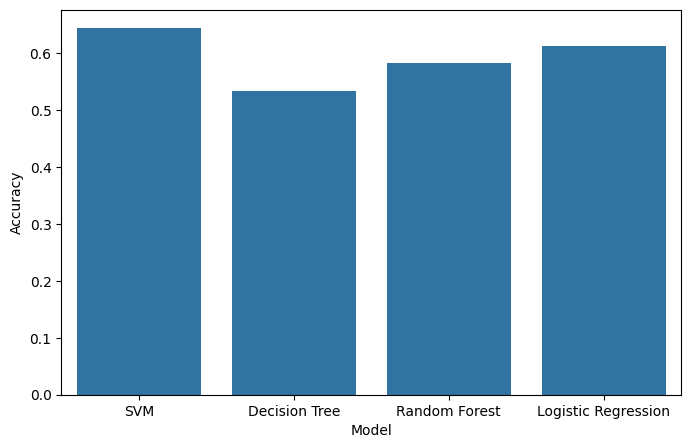

In [123]:
plt.figure(figsize=(8,5))

sns.barplot(

x='Model',

y='Accuracy',

data=comparison

)

plt.show()